In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/Lords internship /housing.csv")
print(df.head())
print("\nDataset Shape: ",df.shape)
print("\nMissing Values: ")
print(df.isnull().sum())
print("\nData Types: ")
print(df.dtypes)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape:  (545, 13)

Missing Values: 
price               0
area                0
bedrooms  

In [3]:
#step 4
x=df.drop('price',axis=1)
y=df[['price']]

In [4]:
print(x.head())
print(y.head())

   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
      price
0  13300000
1  12250000
2  12250000
3  12215000
4  11410000


In [5]:
x = pd.get_dummies(x, drop_first=True)
print(x.head())

   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  7420         4          2        3        2          True          False   
1  8960         4          4        4        3          True          False   
2  9960         3          2        2        2          True          False   
3  7500         4          2        2        3          True          False   
4  7420         4          1        2        2          True           True   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0         False                False                 True          True   
1         False                False                 True         False   
2          True                False                False          True   
3          True                False                 True          True   
4          True                False                 True         False   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0      

In [6]:
#step 6: Data Modelling
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Data:",x_train.shape)
print("Testing Data:",x_test.shape)


Training Data: (436, 13)
Testing Data: (109, 13)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Simple Regression ke liye sirf Area
X_simple = df[["area"]]
y = df["price"]

# Train-test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Prediction
y_pred_s = simple_model.predict(X_test_s)

# Evaluation
mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("Simple Linear Regression")
print("MAE:", mae_s)
print("MSE:", mse_s)
print("R² Score:", r2_s)

Simple Linear Regression
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


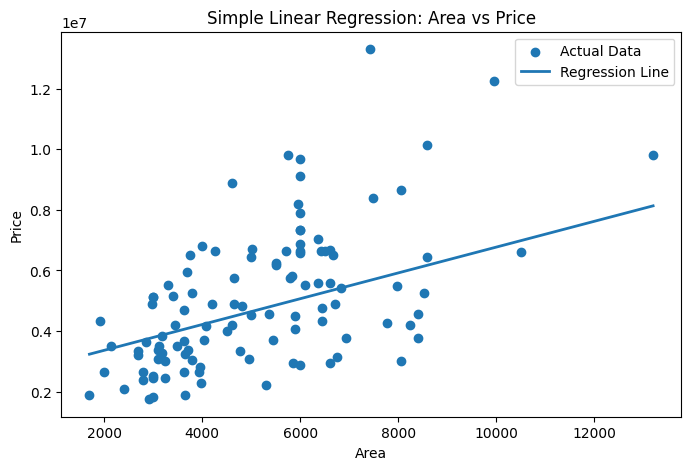

In [10]:

plot_data = pd.DataFrame({
    "area": X_test_s["area"],
    "actual": y_test_s,
    "predicted": y_pred_s
}).sort_values("area")

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_data["area"],
    plot_data["actual"],
    label="Actual Data"
)

plt.plot(
    plot_data["area"],
    plot_data["predicted"],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Area vs Price")
plt.legend()
plt.show()

In [9]:
print("Coefficient:", simple_model.coef_[0])
print("Intercept:", simple_model.intercept_)

Coefficient: 425.72984193878284
Intercept: 2512254.2639593435


In [12]:
# Multiple Linear Regression

multiple_model = LinearRegression()

multiple_model.fit(x_train, y_train)

y_pred_m = multiple_model.predict(x_test)

mae_m = mean_absolute_error(y_test, y_pred_m)
mse_m = mean_squared_error(y_test, y_pred_m)
r2_m = r2_score(y_test, y_pred_m)

print("Multiple Linear Regression")
print("MAE:", mae_m)
print("MSE:", mse_m)
print("R² Score:", r2_m)

Multiple Linear Regression
MAE: 970043.4039201636
MSE: 1754318687330.6638
R² Score: 0.6529242642153184


In [15]:
print("\nCoefficients:")

coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": multiple_model.coef_.ravel()
})

print(coefficients)

print("\nIntercept:", multiple_model.intercept_)


Coefficients:
                            Feature   Coefficient
0                              area  2.359688e+02
1                          bedrooms  7.677870e+04
2                         bathrooms  1.094445e+06
3                           stories  4.074766e+05
4                           parking  2.248419e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
7                      basement_yes  3.902512e+05
8               hotwaterheating_yes  6.846499e+05
9               airconditioning_yes  7.914267e+05
10                     prefarea_yes  6.298906e+05
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05

Intercept: [260032.35760741]


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae_s,
        mae_m
    ],
    "MSE": [
        mse_s,
        mse_m
    ],
    "R2 Score": [
        r2_s,
        r2_m
    ]
})

print(comparison)

                        Model           MAE           MSE  R2 Score
0    Simple Linear Regression  1.474748e+06  3.675287e+12  0.272879
1  Multiple Linear Regression  9.700434e+05  1.754319e+12  0.652924


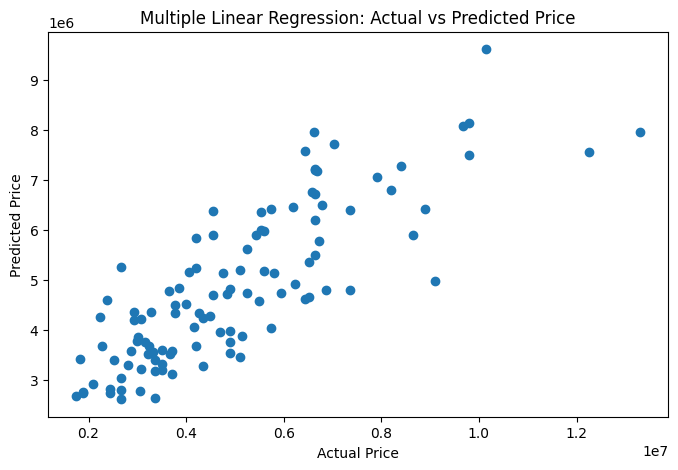

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_m)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted Price")

plt.show()

## Conclusion

Multiple Linear Regression performed better than Simple Linear Regression because it uses multiple features to predict house prices.

The Simple Linear Regression model uses only area as the predictor, while the Multiple Linear Regression model uses multiple house-related features.

The model was evaluated using MAE, MSE and R² score.

The coefficients show how each feature contributes to the predicted house price while keeping other features constant.